In [33]:
# Add the relevant scripts from LArMachineLearningData
# Nice the process so it can run with lots of cores on low priority
import os
os.nice(20)

# Add local paths
import sys
hnlDIR = os.environ['_']
sys.path.append('../pyscript')
sys.path.append('../bdtscript')

# From pyscript Library
from Plotting import *
from Dictionary import *
from HelperFunctions import *
from CutFunctions import *

# From BDT Library
from importlib import reload
from PandoraBDT import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [34]:
#DO NOT INCLUDE NON-FV IN SIGNAL COUNTING
#true_counts =  1035.7422651033662
#start_counts = 986.0935252916531

#INCLUDE NON-FV
true_counts = 1479.8432134638751
start_counts = 1363.0095917609021

In [35]:
simU = 1e-7 #already squared
scaleHNLPlot = 80

In [36]:
plotU = getUfromScaleFactor(simU, scaleHNLPlot)
true_counts = true_counts * scaleHNLPlot
start_counts =  start_counts * scaleHNLPlot

print("Scale Umu by " + str(scaleHNLPlot))
print("Scaled Umu = " + str(plotU))
print("Scaled true counts = " + str(true_counts))
print("Scaled start counts = " + str(start_counts))

Scale Umu by 80
Scaled Umu = 8.944271909999158e-07
Scaled true counts = 118387.45707711001
Scaled start counts = 109040.76734087217


In [37]:
#read in hdf5 to dataframe
hnl_path = "../hdf5_files/hnl_clearcos_bdt_20k.h5"

df_hnl, dfsubrun_hnl, dfmevprtl_hnl, dfmct_hnl = hdf5_to_dataframe(hnl_path)

scale_pot_hnl, hnl_spill = calc_scaling_pot(dfsubrun_hnl, df_hnl, ifScale = scaleHNLPlot)

del dfsubrun_hnl, dfmevprtl_hnl, dfmct_hnl

-----------------------------------------------
sample pot = 1.3514945244223486e+22
sample spill = 20000
target spill = 1479.8432134638754
scale pot factor = 5.9193728538555
-----------------------------------------------


In [38]:
#read in hdf5 to dataframe
nu_path = "../hdf5_files/nu_clearcos_bdt_20k.h5"

df_nu, dfsubrun_nu, _, dfmct_nu = hdf5_to_dataframe(nu_path)

scale_pot_nu, nu_spill = calc_scaling_pot(dfsubrun_nu, df_nu)

del  dfsubrun_nu, dfmct_nu

-----------------------------------------------
sample pot = 2.1545969640795046e+18
sample spill = 19900
target spill = 9236066.10970129
scale pot factor = 464.12392511061756
-----------------------------------------------


In [39]:
#read in hdf5 to dataframe
cos_path = "../hdf5_files/cosmics_clearcos_bdt_20k.h5"

df_cos, _, _, _ = hdf5_to_dataframe(cos_path) 

df_cos, dfsubrun_cosmics, _, _ = hdf5_to_dataframe(cos_path)

scale_pot_cosmics = calc_scaling_spill(dfsubrun_cosmics, df_cos, hnl_spill, nu_spill)

del  dfsubrun_cosmics

-----------------------------------------------
target total spill = 200000000.0
hnl + nu spill = 9237545.952914754
target intime spill = 190762454.04708523
scale pot factor = 99.09737872575856
-----------------------------------------------


In [40]:
df_hnl = df_hnl.drop(['slc_is_clear_cosmics'], axis=1)

df_nu = df_nu.drop(['slc_is_clear_cosmics'], axis=1)

df_cos = df_cos.drop(['slc_is_clear_cosmics'], axis=1)

<h1> CRUMBS </h1>

nSig = 108437, nBkg = 2.48734e+07, nSlc = 2.49819e+07
purity = 0.434
eff = 91.6
select eff = 99.4


<Figure size 432x288 with 0 Axes>

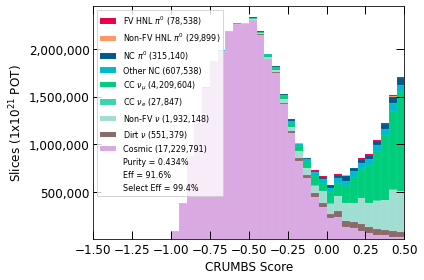

In [41]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_crumbs_score', 
                    scaleHNLPlot,
                    xmin = -1.5, xmax =0.5, xnbin = 40,
                    xtitle = 'CRUMBS Score'
                    )

plt.show()

In [42]:
df_hnl = cutCosmics(df_hnl, crumbsScore = 0)
df_nu = cutCosmics(df_nu, crumbsScore = 0)
df_cos = cutCosmics(df_cos, crumbsScore = 0)

nSig = 100884, nBkg = 7.26104e+06, nSlc = 7.36192e+06
purity = 1.37
eff = 85.2
select eff = 92.5


<Figure size 432x288 with 0 Axes>

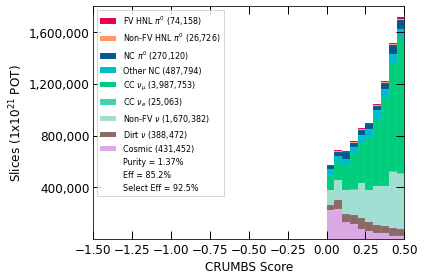

In [43]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_crumbs_score', 
                    scaleHNLPlot,
                    xmin = -1.5, xmax =0.5, xnbin = 40,
                    xtitle = 'CRUMBS Score'
                    )
#plt.yscale('log')

plt.show()

<h1> Fiducial Volume </h1>

nSig = 100884, nBkg = 7.26104e+06, nSlc = 7.36192e+06
purity = 1.37
eff = 85.2
select eff = 92.5


<Figure size 432x288 with 0 Axes>

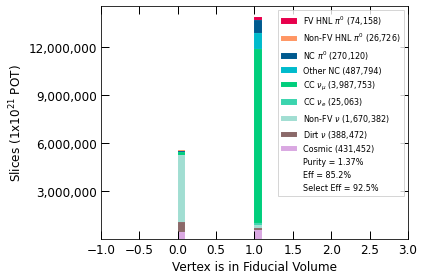

In [44]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_is_fv', 
                    scaleHNLPlot,
                    xmin = -1, xmax = 3, xnbin = 40,
                    xtitle = 'Vertex is in Fiducial Volume'
                    )
plt.show()



In [45]:
df_hnl = cutFV(df_hnl)
df_nu = cutFV(df_nu)
df_cos = cutFV(df_cos)

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

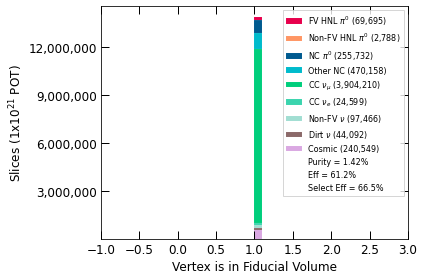

In [46]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_is_fv', 
                    scaleHNLPlot,
                    xmin = -1, xmax = 3, xnbin = 40,
                    xtitle = 'Vertex is in Fiducial Volume'
                    )
plt.show()

<h1>Containment</h1>

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

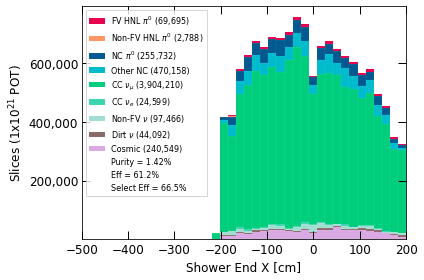

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

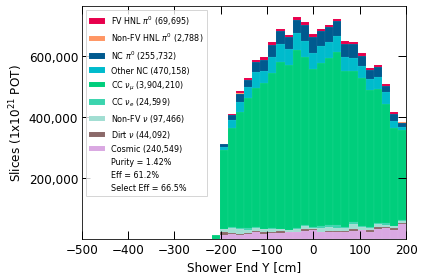

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

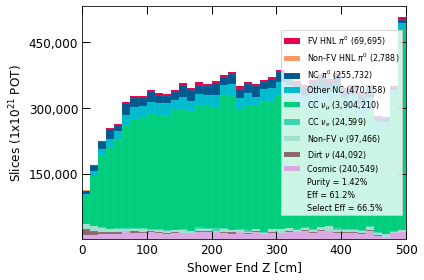

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

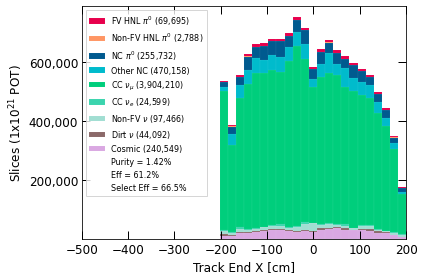

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

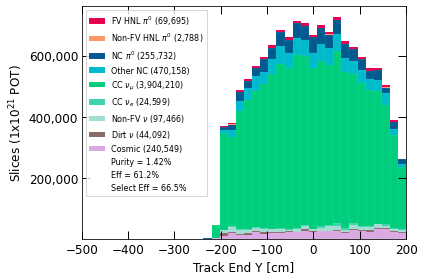

nSig = 72482.7, nBkg = 5.03681e+06, nSlc = 5.10929e+06
purity = 1.42
eff = 61.2
select eff = 66.5


<Figure size 432x288 with 0 Axes>

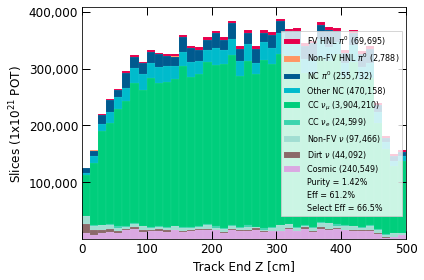

In [47]:
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_x', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Shower End X [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_y', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Shower End Y [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_z', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 500, xnbin = 40,
                    xtitle = 'Shower End Z [cm]'
                    )
plt.show()

#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_x', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Track End X [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_y', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Track End Y [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_z', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 500, xnbin = 40,
                    xtitle = 'Track End Z [cm]'
                    )
plt.show()

In [48]:
df_hnl = cutContainment(df_hnl)
df_nu = cutContainment(df_nu)
df_cos = cutContainment(df_cos)

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

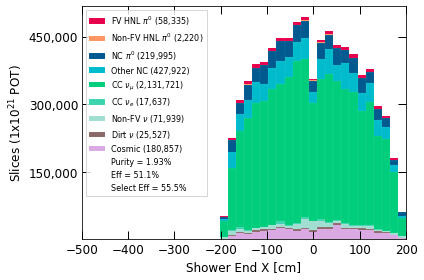

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

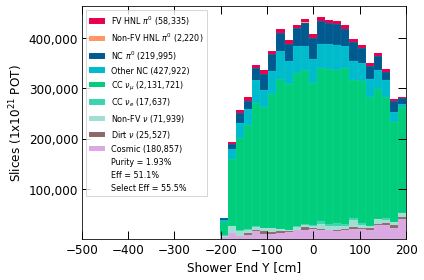

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

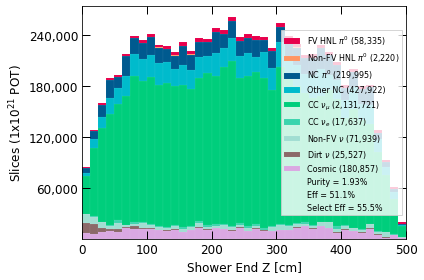

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

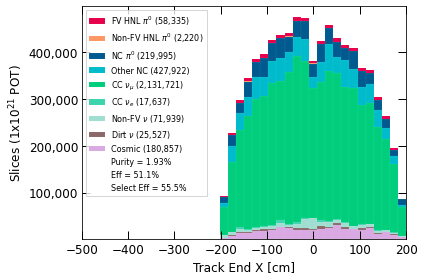

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

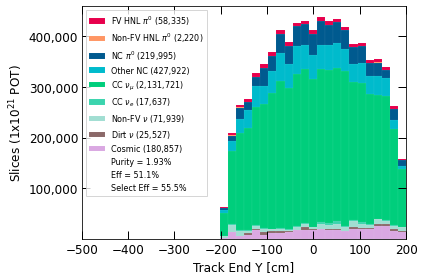

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

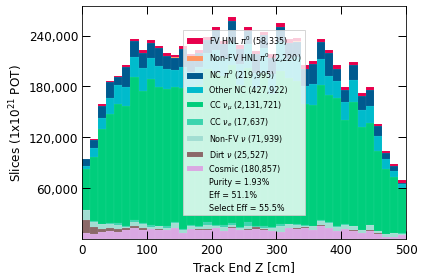

In [49]:
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_x', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Shower End X [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_y', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Shower End Y [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_end_z', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 500, xnbin = 40,
                    xtitle = 'Shower End Z [cm]'
                    )
plt.show()

#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_x', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Track End X [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_y', 
                    scaleHNLPlot,
                    xmin = -500, xmax = 200, xnbin = 40,
                    xtitle = 'Track End Y [cm]'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_end_z', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 500, xnbin = 40,
                    xtitle = 'Track End Z [cm]'
                    )
plt.show()

<h1> Opt0 </h1>

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

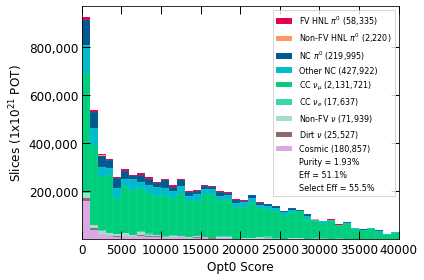

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

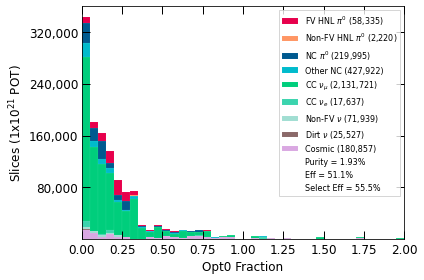

nSig = 60555.2, nBkg = 3.0756e+06, nSlc = 3.13615e+06
purity = 1.93
eff = 51.1
select eff = 55.5


<Figure size 432x288 with 0 Axes>

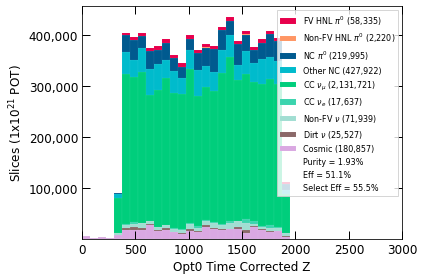

In [50]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 40000, xnbin = 40,
                    xtitle = 'Opt0 Score'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_frac', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 2, xnbin = 40,
                    xtitle = 'Opt0 Fraction'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_time_corrected_Z_pandora', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 3000, xnbin = 40,
                    xtitle = 'Opt0 Time Corrected Z'
                    )
plt.show()

In [51]:
df_hnl = cutOpt0(df_hnl)
df_nu = cutOpt0(df_nu)
df_cos = cutOpt0(df_cos)

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

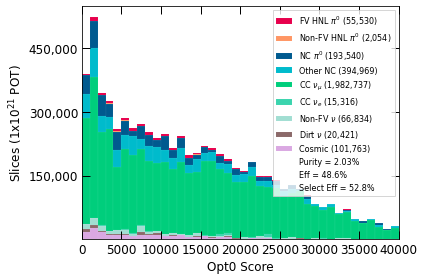

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

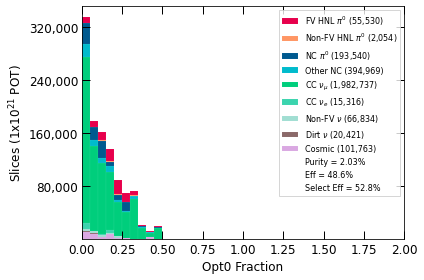

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

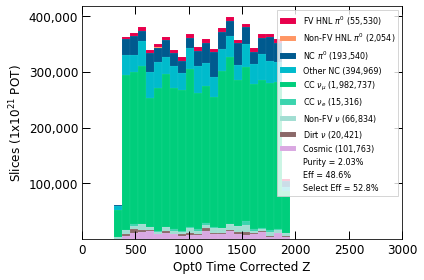

In [52]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 40000, xnbin = 40,
                    xtitle = 'Opt0 Score'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_frac', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 2, xnbin = 40,
                    xtitle = 'Opt0 Fraction'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_opt0_time_corrected_Z_pandora', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 3000, xnbin = 40,
                    xtitle = 'Opt0 Time Corrected Z'
                    )
plt.show()

<h1> Make Beam Bucket - Pre PID</h1>

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

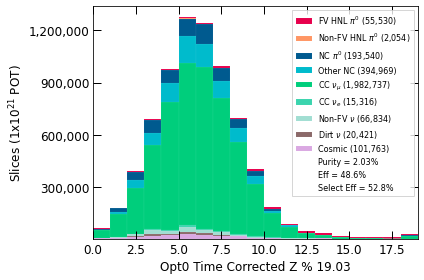

In [53]:
width = 19.03

df_hnl['mod_t'] = df_hnl['slc_opt0_time_corrected_Z_pandora']%width
df_nu['mod_t'] = df_nu['slc_opt0_time_corrected_Z_pandora']%width
df_cos['mod_t'] = df_cos['slc_opt0_time_corrected_Z_pandora']%width
#----------------------------------------------
hist, bins = plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'mod_t', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 19, xnbin = 19,
                    xtitle = 'Opt0 Time Corrected Z % ' + str(width)
                    )
plt.show()

<h1>Muon Rejection</h1>

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

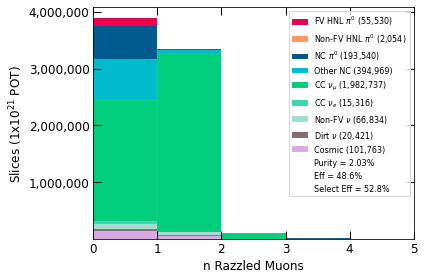

nSig = 57583.7, nBkg = 2.77558e+06, nSlc = 2.83316e+06
purity = 2.03
eff = 48.6
select eff = 52.8


<Figure size 432x288 with 0 Axes>

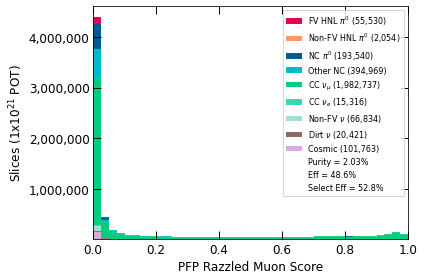

In [54]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_muons', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Muons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_muon_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Muon Score'
                    )
plt.show()

In [55]:
df_hnl = cutMuon(df_hnl, muonScore = 0.04)
df_nu = cutMuon(df_nu, muonScore = 0.04)
df_cos = cutMuon(df_cos, muonScore = 0.04)

nSig = 49935.8, nBkg = 607287, nSlc = 657223
purity = 7.6
eff = 42.2
select eff = 45.8


<Figure size 432x288 with 0 Axes>

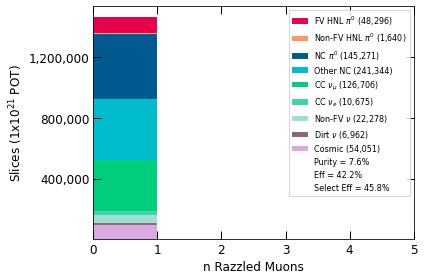

nSig = 49935.8, nBkg = 607287, nSlc = 657223
purity = 7.6
eff = 42.2
select eff = 45.8


<Figure size 432x288 with 0 Axes>

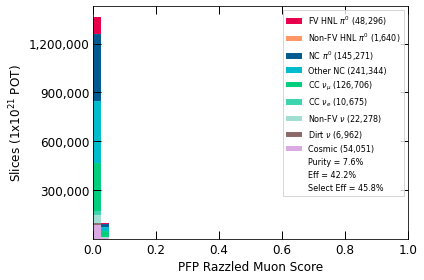

In [56]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_muons', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Muons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_muon_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Muon Score'
                    )
#plt.xlim(0,0.04)
plt.show()

<h1>Proton Rejection</h1>

nSig = 49935.8, nBkg = 607287, nSlc = 657223
purity = 7.6
eff = 42.2
select eff = 45.8


<Figure size 432x288 with 0 Axes>

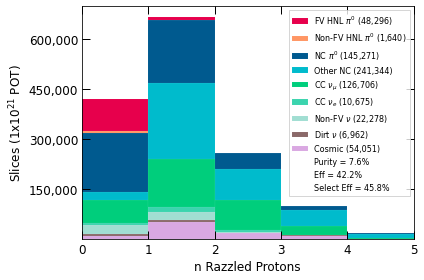

nSig = 49935.8, nBkg = 607287, nSlc = 657223
purity = 7.6
eff = 42.2
select eff = 45.8


<Figure size 432x288 with 0 Axes>

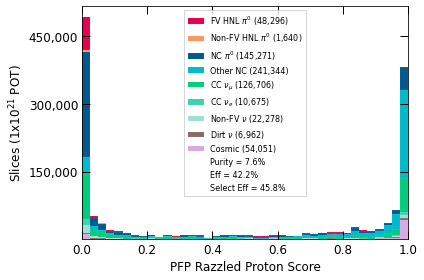

In [57]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_protons_thresh', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Protons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_proton_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Proton Score'
                    )
#plt.xlim(0,0.04)
plt.show()

In [58]:
df_hnl = cutProton(df_hnl, nProton = 0, protonScore = 0.025)
df_nu = cutProton(df_nu, nProton = 0, protonScore = 0.025)
df_cos = cutProton(df_cos, nProton = 0, protonScore = 0.025)

nSig = 28602.4, nBkg = 55986.9, nSlc = 84589.3
purity = 33.8
eff = 24.2
select eff = 26.2


<Figure size 432x288 with 0 Axes>

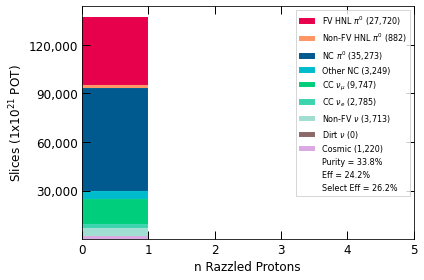

nSig = 28602.4, nBkg = 55986.9, nSlc = 84589.3
purity = 33.8
eff = 24.2
select eff = 26.2


<Figure size 432x288 with 0 Axes>

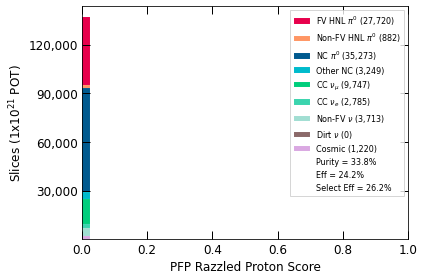

In [59]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_protons_thresh', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Protons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_proton_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Proton Score'
                    )
plt.show()

<h1>Pion Rejection</h1>

nSig = 28602.4, nBkg = 55986.9, nSlc = 84589.3
purity = 33.8
eff = 24.2
select eff = 26.2


<Figure size 432x288 with 0 Axes>

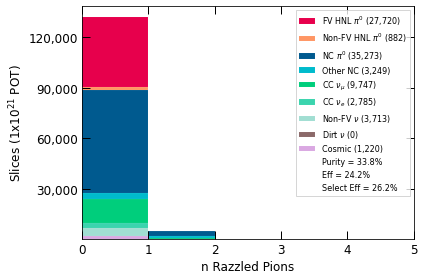

nSig = 28602.4, nBkg = 55986.9, nSlc = 84589.3
purity = 33.8
eff = 24.2
select eff = 26.2


<Figure size 432x288 with 0 Axes>

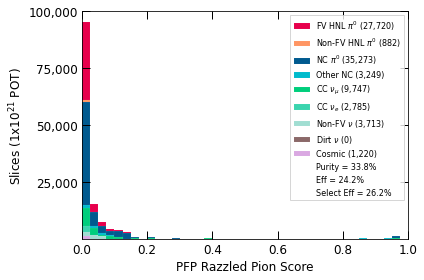

In [60]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_pions_thresh', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Pions'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_pion_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Pion Score'
                    )
plt.show()

In [61]:
df_hnl = cutPion(df_hnl, nPion = 0, pionScore = 0.7)
df_nu = cutPion(df_nu, nPion = 0, pionScore = 0.7)
df_cos = cutPion(df_cos, nPion = 0, pionScore = 0.7)

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

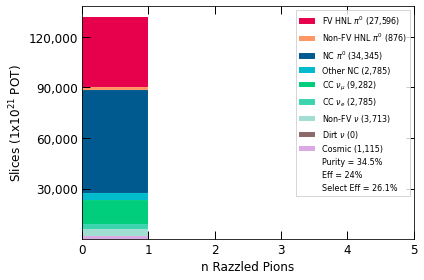

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

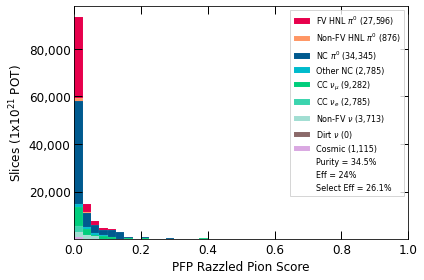

In [62]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_pions_thresh', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Pions'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_pion_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Pion Score'
                    )
plt.show()

<h1>Electron Rejection (?)</h1>

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

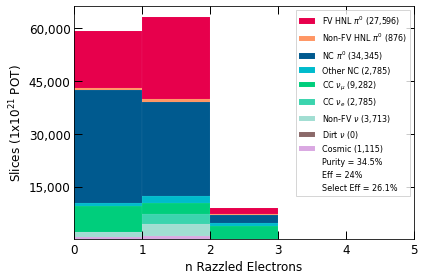

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

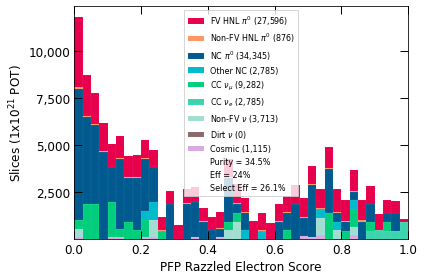

In [63]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_electrons', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 5, xnbin = 5,
                    xtitle = 'n Razzled Electrons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_electron_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Electron Score'
                    )
plt.show()

<h1>Photon Selection</h1>

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

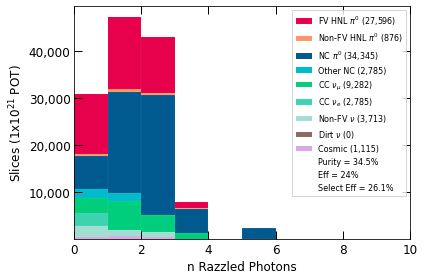

nSig = 28472.2, nBkg = 54025.4, nSlc = 82497.6
purity = 34.5
eff = 24
select eff = 26.1


<Figure size 432x288 with 0 Axes>

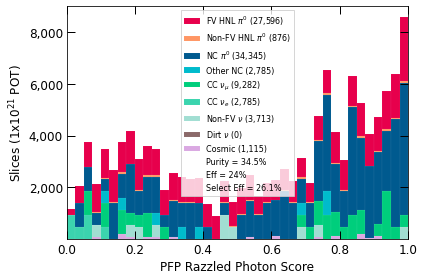

In [64]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_photons', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 10, xnbin = 10,
                    xtitle = 'n Razzled Photons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_photon_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Photon Score'
                    )
plt.show()

In [65]:
df_hnl = cutPhoton(df_hnl, nPhoton = 2, ifScore = False)
df_nu = cutPhoton(df_nu, nPhoton = 2, ifScore = False)
df_cos = cutPhoton(df_cos, nPhoton = 2, ifScore = False)

nSig = 28004.6, nBkg = 51704.8, nSlc = 79709.3
purity = 35.1
eff = 23.7
select eff = 25.7


<Figure size 432x288 with 0 Axes>

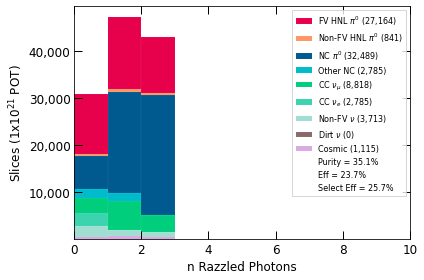

nSig = 28004.6, nBkg = 51704.8, nSlc = 79709.3
purity = 35.1
eff = 23.7
select eff = 25.7


<Figure size 432x288 with 0 Axes>

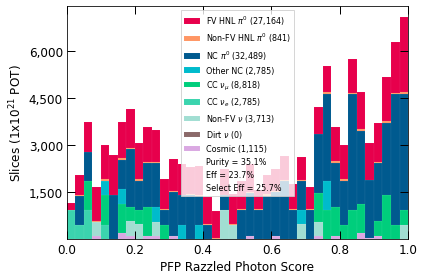

In [66]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_n_razzled_photons', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 10, xnbin = 10,
                    xtitle = 'n Razzled Photons'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_razzled_photon_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 40,
                    xtitle = 'PFP Razzled Photon Score'
                    )
plt.show()

<h1>Shower Topology</h1>

In [67]:
#Look at only primary shower
def cutHighestShowerE(df):
    df = df[df['slc_pfp_shower_energy'] == df.groupby(['run','subrun','event','slc_idx'])["slc_pfp_shower_energy"].transform(max)]
    return df

df_hnl = cutHighestShowerE(df_hnl) 
df_nu = cutHighestShowerE(df_nu) 
df_cos = cutHighestShowerE(df_cos) 

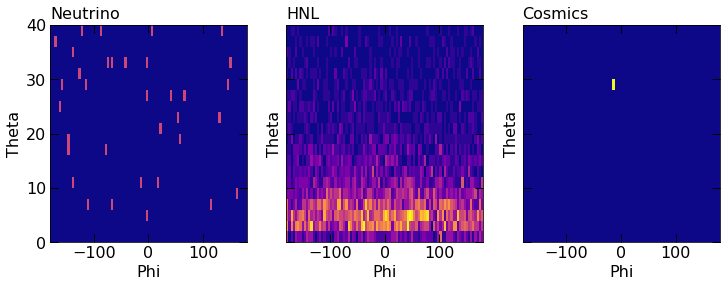

In [68]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey= True, sharex = True)

xmin, xmax = -180, 180
xnbin = 90

ymin, ymax = 0, 180
ynbin = 90

xlimmin, xlimmax = xmin, xmax
ylimmin, ylimmax = ymin, ymax
#----------------------------------------------
plot_2dhist( df_nu['slc_pfp_shower_phi'], df_nu['slc_pfp_shower_theta'], 
            ax1, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_nu['scale_pot'],
            title = 'Neutrino', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plot_2dhist( df_hnl['slc_pfp_shower_phi'], df_hnl['slc_pfp_shower_theta'], 
            ax2, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_hnl['scale_pot'],
            title = 'HNL', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plot_2dhist( df_cos['slc_pfp_shower_phi'], df_cos['slc_pfp_shower_theta'], 
            ax3, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_cos['scale_pot'],
            title = 'Cosmics', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plt.ylim(0,40)
plt.show()

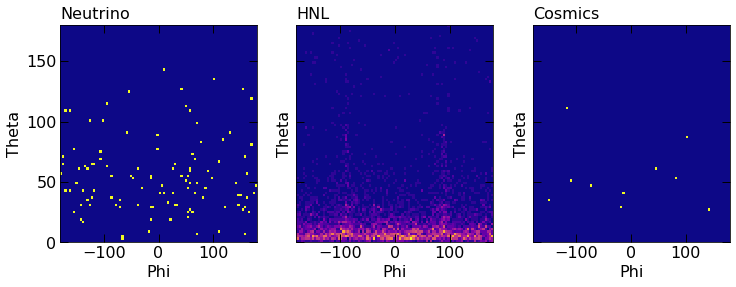

In [69]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey= True, sharex = True)

xmin, xmax = -180, 180
xnbin = 90

ymin, ymax = 0, 180
ynbin = 90

xlimmin, xlimmax = xmin, xmax
ylimmin, ylimmax = ymin, ymax
#----------------------------------------------
plot_2dhist( df_nu['slc_pfp_track_phi'], df_nu['slc_pfp_track_theta'], 
            ax1, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_nu['scale_pot'],
            title = 'Neutrino', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plot_2dhist( df_hnl['slc_pfp_track_phi'], df_hnl['slc_pfp_track_theta'], 
            ax2, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_hnl['scale_pot'],
            title = 'HNL', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plot_2dhist( df_cos['slc_pfp_track_phi'], df_cos['slc_pfp_track_theta'], 
            ax3, fig, 
            xmin, xmax, ymin, ymax, xnbin, ynbin,
            xlimmin, xlimmax, ylimmin, ylimmax,
            weights = df_cos['scale_pot'],
            title = 'Cosmics', xtitle = 'Phi', ytitle= 'Theta'
                )
#----------------------------------------------
plt.show()

nSig = 28004.6, nBkg = 51704.8, nSlc = 79709.3
purity = 35.1
eff = 23.7
select eff = 25.7


<Figure size 432x288 with 0 Axes>

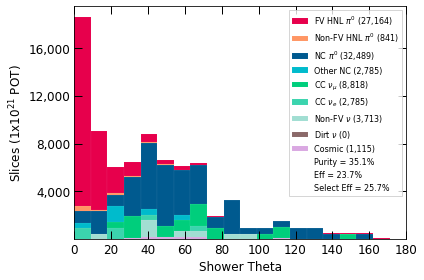

nSig = 28004.6, nBkg = 51704.8, nSlc = 79709.3
purity = 35.1
eff = 23.7
select eff = 25.7


<Figure size 432x288 with 0 Axes>

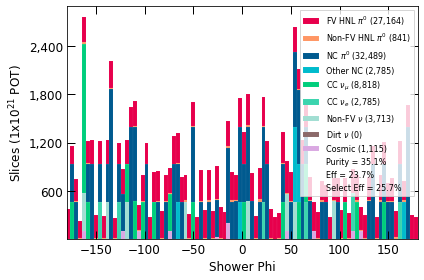

In [70]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_theta', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 180, xnbin = 20,
                    xtitle = 'Shower Theta'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_phi', 
                    scaleHNLPlot,
                    xmin = -180, xmax = 180, xnbin = 90,
                    xtitle = 'Shower Phi'
                    )
plt.show()

In [71]:
df_hnl = cutThetaAngle(df_hnl, thetaAngle = 10) 
df_nu = cutThetaAngle(df_nu, thetaAngle = 10) 
df_cos = cutThetaAngle(df_cos, thetaAngle = 10) 

nSig = 17349.7, nBkg = 2326.54, nSlc = 19676.2
purity = 88.2
eff = 14.7
select eff = 15.9


<Figure size 432x288 with 0 Axes>

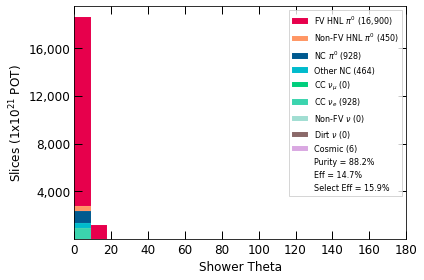

nSig = 17349.7, nBkg = 2326.54, nSlc = 19676.2
purity = 88.2
eff = 14.7
select eff = 15.9


<Figure size 432x288 with 0 Axes>

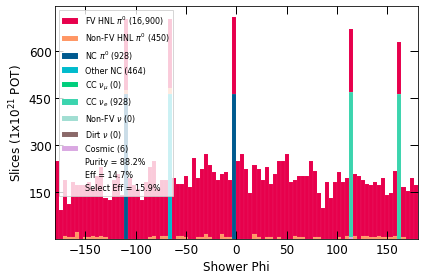

In [72]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_theta', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 180, xnbin = 20,
                    xtitle = 'Shower Theta'
                    )
plt.show()
#----------------------------------------------
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_shower_phi', 
                    scaleHNLPlot,
                    xmin = -180, xmax = 180, xnbin = 90,
                    xtitle = 'Shower Phi'
                    )
plt.show()

<h1>Track Score</h1>

nSig = 17349.7, nBkg = 2326.54, nSlc = 19676.2
purity = 88.2
eff = 14.7
select eff = 15.9


<Figure size 432x288 with 0 Axes>

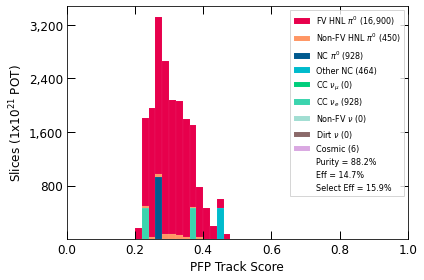

In [73]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 50,
                    xtitle = 'PFP Track Score'
                    )

#plt.xlim(0.4,0.6)
plt.show()

In [74]:
df_hnl = cutTrackScore(df_hnl, TrackScore = 0.45) 
df_nu = cutTrackScore(df_nu, TrackScore = 0.45) 
df_cos = cutTrackScore(df_cos, TrackScore = 0.45) 

nSig = 17219.5, nBkg = 1862.42, nSlc = 19081.9
purity = 90.2
eff = 14.5
select eff = 15.8


<Figure size 432x288 with 0 Axes>

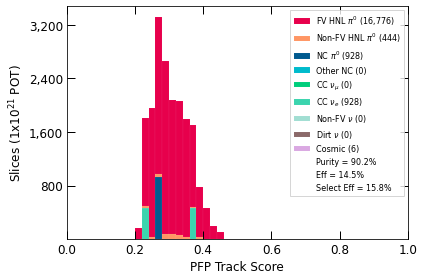

In [75]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'slc_pfp_track_score', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 1, xnbin = 50,
                    xtitle = 'PFP Track Score'
                    )

#plt.xlim(0.4,0.6)
plt.show()

<h1> Make Beam Bucket - Post PID</h1>

nSig = 17219.5, nBkg = 1862.42, nSlc = 19081.9
purity = 90.2
eff = 14.5
select eff = 15.8


<Figure size 432x288 with 0 Axes>

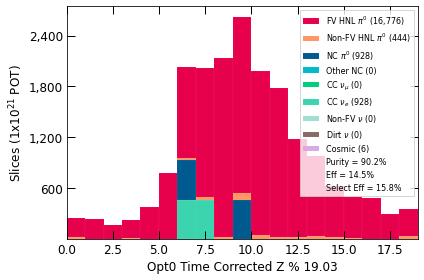

In [139]:
hist, bins = plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'mod_t', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 19, xnbin = 19,
                    xtitle = 'Opt0 Time Corrected Z % ' + str(width)
                    )
plt.show()

<h1>Make 1D Histogram</h1>

In [140]:
print(df_hnl['slc_true_event_type'].unique())
print(df_nu['slc_true_event_type'].unique())
print(df_cos['slc_true_event_type'].unique())

[0 1 9]
[6 3]
[]


In [141]:
df_hnl['signal']= df_hnl['slc_true_event_type']<=1
df_nu['signal']= df_nu['slc_true_event_type']<=1
df_cos['signal']= df_cos['slc_true_event_type']<=1

nSig = 17219.5, nBkg = 1862.42, nSlc = 19081.9
purity = 90.2
eff = 14.5
select eff = 15.8


<Figure size 432x288 with 0 Axes>

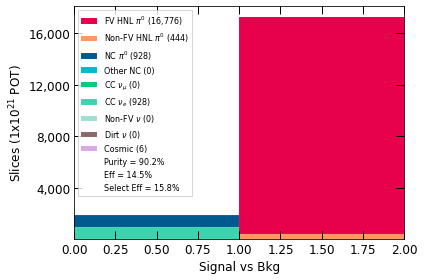

In [142]:
plot_slc_var(df_hnl, df_nu, df_cos,
                    true_counts, start_counts, 
                    'signal', 
                    scaleHNLPlot,
                    xmin = 0, xmax = 2, xnbin = 2,
                    xtitle = 'Signal vs Bkg'
                    )

#plt.ylim(0,10000)
plt.show()

In [143]:
print(hist.shape)
print(bins.shape)
print(len(hist))
print(hist[0])

(9, 19)
(20,)
9
[ 230.8555413   242.69428701  171.66181276  219.01679559  372.92048979
  769.518471   1083.24523226 1521.27882344 2107.29673597 2071.78049885
 1935.63492321 1758.0537376  1154.2777065   941.18028376  597.85665824
  485.38857402  491.30794687  295.96864269  325.56550696]


In [144]:
sigHist = np.zeros(len(hist[0]))

for i in range(0, 2):
    sigHist = np.add(sigHist, hist[i])
    
print(sigHist)
print("Total Signal in histogram = " +str(np.sum(sigHist)))

[ 254.53303272  242.69428701  171.66181276  230.8555413   378.83986265
  775.43784386 1106.92272367 1556.79506056 2136.89360024 2148.73234595
 1982.98990604 1787.65060186 1183.87457077  982.61589374  621.53414965
  503.14669258  491.30794687  301.88801555  361.08174409]
Total Signal in histogram = 17219.455631866113


In [145]:
bkgHist = np.zeros(len(hist[0]))

for i in range(2, 9):
    bkgHist = np.add(bkgHist, hist[i])
    
print(bkgHist)
print("Total Background in histogram = " +str(np.sum(bkgHist)))

[  0.           0.           0.           0.           0.
   0.         928.24785022 464.12392511   0.         464.12392511
   0.           0.           0.           0.           5.91937285
   0.           0.           0.           0.        ]
Total Background in histogram = 1862.4150732963258


In [146]:
print(bins)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]


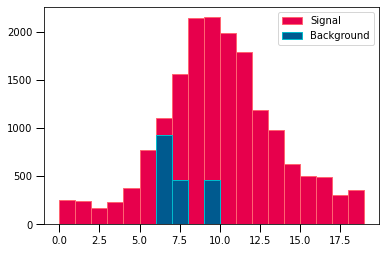

In [147]:
fig, ax = plt.subplots(1, 1, figsize = (6, 4))

ax.bar(x=bins[:-1], 
       height=sigHist, 
       width=np.diff(bins), 
       align='edge', 
       label='Signal',
       fc=col_dict['Coral'], 
       ec = col_dict['Flamingo'],
       linewidth = 1)

ax.bar(x=bins[:-1], 
       height=bkgHist, 
       width=np.diff(bins), 
       align='edge', 
       label='Background',
       fc=col_dict['Teal'], 
       ec=col_dict['Aqua'],
       linewidth = 1)
plt.legend()
plt.show()

In [169]:
lb = 10
ub = 1
binsFit = bins[lb:]
sigFit = sigHist[lb:]
bkgFit = bkgHist[lb:]

In [170]:
print(binsFit)
print(sigFit)
print(bkgFit)


[10. 11. 12. 13. 14. 15. 16. 17. 18. 19.]
[1982.98990604 1787.65060186 1183.87457077  982.61589374  621.53414965
  503.14669258  491.30794687  301.88801555  361.08174409]
[0.         0.         0.         0.         5.91937285 0.
 0.         0.         0.        ]


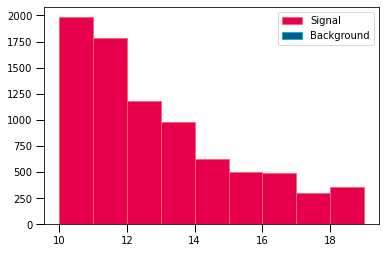

In [171]:
fig, ax = plt.subplots(1, 1, figsize = (6, 4))

ax.bar(x=binsFit[:-1], 
       height=sigFit, 
       width=np.diff(binsFit), 
       align='edge', 
       label='Signal',
       fc=col_dict['Coral'], 
       ec = col_dict['Flamingo'],
       linewidth = 1)

ax.bar(x=binsFit[:-1], 
       height=bkgFit, 
       width=np.diff(binsFit), 
       align='edge', 
       label='Background',
       fc=col_dict['Teal'], 
       ec=col_dict['Aqua'],
       linewidth = 1)
plt.legend()
plt.show()

<h1>Scaling to ~10 events for hypothesis testing </h1>

In [172]:
print("Before Scaling")
print(sigFit)
print(bkgFit)

Before Scaling
[1982.98990604 1787.65060186 1183.87457077  982.61589374  621.53414965
  503.14669258  491.30794687  301.88801555  361.08174409]
[0.         0.         0.         0.         5.91937285 0.
 0.         0.         0.        ]


In [173]:
scaleHNLFit = 1/300

sigFit = sigFit * scaleHNLFit
print("After Scaling")
print(sigFit)
print(bkgFit)

After Scaling
[6.60996635 5.95883534 3.94624857 3.27538631 2.0717805  1.67715564
 1.63769316 1.00629339 1.20360581]
[0.         0.         0.         0.         5.91937285 0.
 0.         0.         0.        ]


In [174]:
fitU = getUfromScaleFactor(plotU, scaleHNLFit)
print('simU = ' +str(simU))
print('plotU = ' + str(plotU))
print('fitU = ' +str(fitU))

simU = 1e-07
plotU = 8.944271909999158e-07
fitU = 5.1639777949432226e-08


In [175]:
bkgStatErr = 1/np.sqrt(bkgFit)
sigStatErr = 1/np.sqrt(sigFit)

print(bkgStatErr)
print(sigStatErr)

[       inf        inf        inf        inf 0.41101924        inf
        inf        inf        inf]
[0.38895591 0.40965599 0.50339371 0.55254638 0.69474932 0.7721707
 0.78141858 0.99686808 0.91150249]


In [176]:
sigFit = sigFit.tolist()
bkgFit = bkgFit.tolist()
bkgStatErr = bkgStatErr.tolist()
sigStatErr = sigStatErr.tolist()


<h1> Counting Experiment / Sum All Bins</h1>

In [177]:
import pyhf
import numpy as np
import matplotlib.pyplot as plt
from pyhf.contrib.viz import brazil

pyhf.set_backend("numpy")

In [178]:
sigTot = np.sum(sigFit)
sigTotErr = np.sqrt(sigTot)

bkgTot = np.sum(bkgFit)
bkgTotErr = np.sqrt(bkgTot)

print(sigTot)
print(bkgTot)
print(bkgTotErr)

27.386965070505894
5.9193728538555
2.4329761309670714


In [179]:
model_dict = pyhf.Model(
        {
      "channels": [
        {
          "name": "singlechannel",
          "samples": [
            {
              "name": "signal",
              "data": [sigTot],
              "modifiers": [
                {"name": "mu", "type": "normfactor", "data": None}, #This is the scaling which is to be calculated
                {"name": "uncorr_siguncrt", "type": "shapesys", "data": [sigTotErr]}
              ]
            },
            {
              "name": "background",
              "data": [bkgTot],
              "modifiers": [
                {"name": "uncorr_bkguncrt", "type": "shapesys", "data": [bkgTotErr]}
              ]
            }
          ]
        }
      ]
    }
    )

print(f'Samples:\n {model_dict.config.samples}')
print(f'Modifiers are:\n {model_dict.config.modifiers}')

Samples:
 ['background', 'signal']
Modifiers are:
 [('mu', 'normfactor'), ('uncorr_bkguncrt', 'shapesys'), ('uncorr_siguncrt', 'shapesys')]


In [180]:
# No DATA --> Data == Background

data = [bkgTot]+model_dict.config.auxdata

In [181]:
#poi_values = np.linspace(0.001, 2, 50)
poi_values = np.linspace(0, 10, 41)

obs_limit_single, exp_limits_single, (scan, results) = pyhf.infer.intervals.upper_limits.upper_limit(data, 
                                                                                        model_dict, 
                                                                                        poi_values, 
                                                                                        level=0.1, 
                                                                                        return_results=True)

print(f"Upper limit (obs): μ = {obs_limit_single:.4f}")
print(f"Upper limit (exp): μ = {exp_limits_single[2]:.4f}" + "\n")

Upper limit (obs): μ = 0.2432
Upper limit (exp): μ = 0.2432



In [182]:
EXP_LIMIT = np.sqrt(exp_limits_single[2])*fitU
LIMIT = np.sqrt(obs_limit_single)*fitU
print(f"Expected limit is " + str(EXP_LIMIT))
print(f"Observed limit is " + str(LIMIT)+ "\n")

Expected limit is 2.5467025745681826e-08
Observed limit is 2.5467025745681826e-08



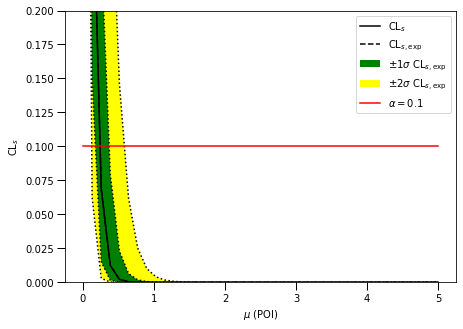

In [183]:
poi_vals = np.linspace(0, 5, 40)

results = [
    pyhf.infer.hypotest(
        test_poi, data, model_dict, test_stat="qtilde", return_expected_set=True
    )
    for test_poi in poi_vals
]

fig, ax = plt.subplots()
fig.set_size_inches(7, 5)
brazil.plot_results(poi_vals, results, ax=ax, test_size=0.10,)
plt.ylim(0.0,0.2)
fig.show()

<h1> Histogram Fit</h1>

In [184]:
model_dict = pyhf.Model(
        {
      "channels": [
        {
          "name": "singlechannel",
          "samples": [
            {
              "name": "signal",
              "data": sigFit,
              "modifiers": [
                {"name": "mu", "type": "normfactor", "data": None}, #This is the scaling which is to be calculated
                {"name": "uncorr_siguncrt", "type": "shapesys", "data": sigStatErr}
              ]
            },
            {
              "name": "background",
              "data": bkgFit,
              "modifiers": [
                {"name": "uncorr_bkguncrt", "type": "shapesys", "data": bkgStatErr}
              ]
            }
          ]
        }
      ]
    }
    )

print(f'Samples:\n {model_dict.config.samples}')
print(f'Modifiers are:\n {model_dict.config.modifiers}')

Samples:
 ['background', 'signal']
Modifiers are:
 [('mu', 'normfactor'), ('uncorr_bkguncrt', 'shapesys'), ('uncorr_siguncrt', 'shapesys')]


In [185]:
# No DATA --> Data == Background

data = bkgFit+model_dict.config.auxdata

In [186]:
#poi_values = np.linspace(0.001,5, 50)
poi_values = np.linspace(0, 5, 50)

obs_limit_single, exp_limits_single, (scan, results) = pyhf.infer.intervals.upper_limits.upper_limit(data, 
                                                                                        model_dict, 
                                                                                        poi_values, 
                                                                                        level=0.1, 
                                                                                        return_results=True)

print(f"Upper limit (obs): μ = {obs_limit_single:.4f}")
print(f"Upper limit (exp): μ = {exp_limits_single[2]:.4f}" + "\n")

Upper limit (obs): μ = 0.0940
Upper limit (exp): μ = 0.0940



In [187]:
EXP_LIMIT = np.sqrt(exp_limits_single[2])*fitU
LIMIT = np.sqrt(obs_limit_single)*fitU
print(f"Expected limit is " + str(EXP_LIMIT))
print(f"Observed limit is " + str(LIMIT)+ "\n")

Expected limit is 1.5836065899229967e-08
Observed limit is 1.5836065899229967e-08



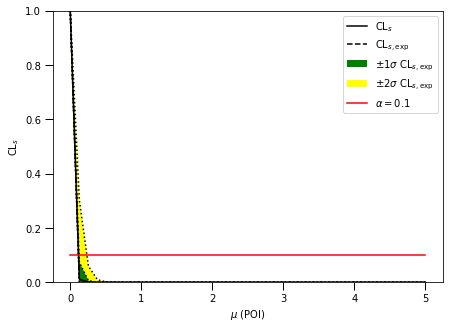

In [188]:
poi_vals = np.linspace(0, 5, 40)

results = [
    pyhf.infer.hypotest(
        test_poi, data, model_dict, test_stat="qtilde", return_expected_set=True
    )
    for test_poi in poi_vals
]

fig, ax = plt.subplots()
fig.set_size_inches(7, 5)
brazil.plot_results(poi_vals, results, ax=ax, test_size=0.10,)
fig.show()